# xgb_wrapped Training Notebook\nOptimized for IntrusionSense-IDS

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import multilabel_confusion_matrix, classification_report, confusion_matrix
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# 1. Load the unified dataset
data_path = '../data/processed/master_dataset.csv'
df = pd.read_csv(data_path)
print("Dataset shape:", df.shape)
print("Label Distribution:")
print(df['Label'].value_counts())

Dataset shape: (166015, 79)
Label Distribution:
Label
BENIGN                        50000
PortScan                      50000
DoS Hulk                      45851
FTP-Patator                    7938
SSH-Patator                    5897
DoS GoldenEye                  2003
Web Attack � Brute Force       1507
DoS slowloris                  1089
DoS Slowhttptest               1055
Web Attack � XSS                652
Web Attack � Sql Injection       21
Heartbleed                        2
Name: count, dtype: int64


In [3]:
# 2. Preprocessing
def map_attack_label(label):
    label = str(label).strip()
    if label == 'BENIGN':
        return 0
    elif 'DoS' in label:
        return 1
    elif 'PortScan' in label:
        return 2
    elif 'Patator' in label:
        return 3
    elif 'Web Attack' in label:
        return 4
    else:
        return 5

if 'Label' not in df.columns:
    if 'Attack_Type' in df.columns:
        df = df.rename(columns={'Attack_Type': 'Label'})

y = df['Label'].apply(map_attack_label)
X = df.drop(columns=['Label'])

# Ensure numeric types
X = X.apply(pd.to_numeric, errors='coerce')
X.replace([np.inf, -np.inf], 0, inplace=True)
X.fillna(0, inplace=True)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [4]:
# 3. XGBoost Training
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights for imbalance
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
sample_weights = np.array([weights[idx] for idx in y_train])

print("Training XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train, sample_weight=sample_weights)


Training XGBoost...


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


d:\Python\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Python\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Python\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     15000
           1       1.00      1.00      1.00     15000
           2       1.00      1.00      1.00     15000
           3       1.00      1.00      1.00      4150
           4       0.99      0.99      0.99       654
           5       0.00      0.00      0.00         1

    accuracy                           1.00     49805
   macro avg       0.83      0.83      0.83     49805
weighted avg       1.00      1.00      1.00     49805



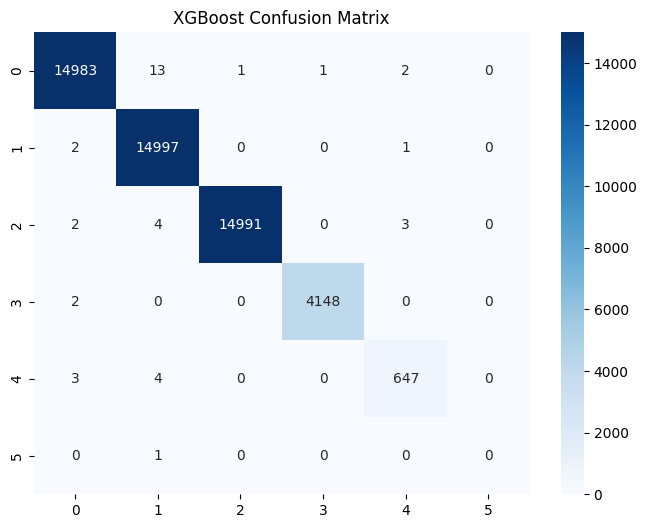

In [5]:
# 4. Evaluation
y_pred = xgb_model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost Confusion Matrix')
plt.show()

In [6]:
# 5. Export Models
os.makedirs('../src/models', exist_ok=True)
model_path = '../src/models/multiClass_ids_model_xgboost.pkl'
features_path = '../src/models/model_features_xgboost.pkl'

joblib.dump(xgb_model, model_path)
joblib.dump(list(X.columns), features_path)

print(f"Successfully saved model to {model_path}")
print(f"Successfully saved features to {features_path}")

Successfully saved model to ../src/models/multiClass_ids_model_xgboost.pkl
Successfully saved features to ../src/models/model_features_xgboost.pkl
